<a href="https://colab.research.google.com/github/AliSalman25/first-Jupyter-Notebook-for-the-experiments/blob/main/first_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

            Price
Date             
2003-01-02  30.05
2003-01-03  30.83
2003-01-06  30.71
2003-01-07  29.72
2003-01-08  28.86


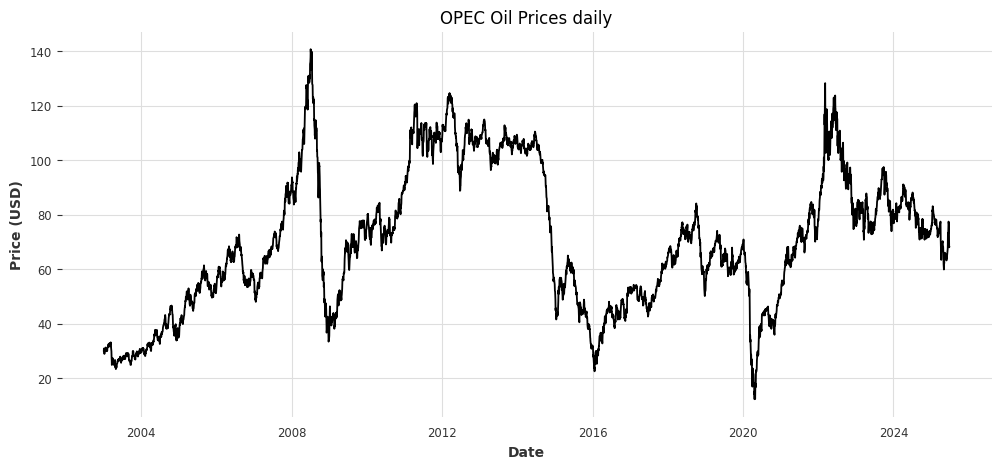

In [ ]:
# الخطوة 1: استيراد المكتبات
import pandas as pd
import matplotlib.pyplot as plt

# تحميل البيانات
file_path = '/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/Dataset.csv'
df = pd.read_csv(file_path)

# تحويل العمود Date إلى نوع تاريخي
df['Date'] = pd.to_datetime(df['Date'])

# ضبط التاريخ كمؤشر للبيانات
df.set_index('Date', inplace=True)

# عرض أول خمس صفوف
print(df.head())

# رسم السلسلة الزمنية
plt.figure(figsize=(12,5))
plt.plot(df['Price'])
plt.title('OPEC Oil Prices daily')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# الخطوة 2: التحقق من الثبات باستخدام اختبار ADF
from statsmodels.tsa.stattools import adfuller

# تنفيذ الاختبار
result = adfuller(df['Price'])

# عرض النتائج
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Used Lags:', result[2])
print('Number of Observations:', result[3])
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')


ADF Statistic: -2.969114269366679
p-value: 0.037881148719252675
Used Lags: 32
Number of Observations: 5766
Critical Values:
   1%: -3.4314846190761017
   5%: -2.862041393601955
   10%: -2.5670368899004763


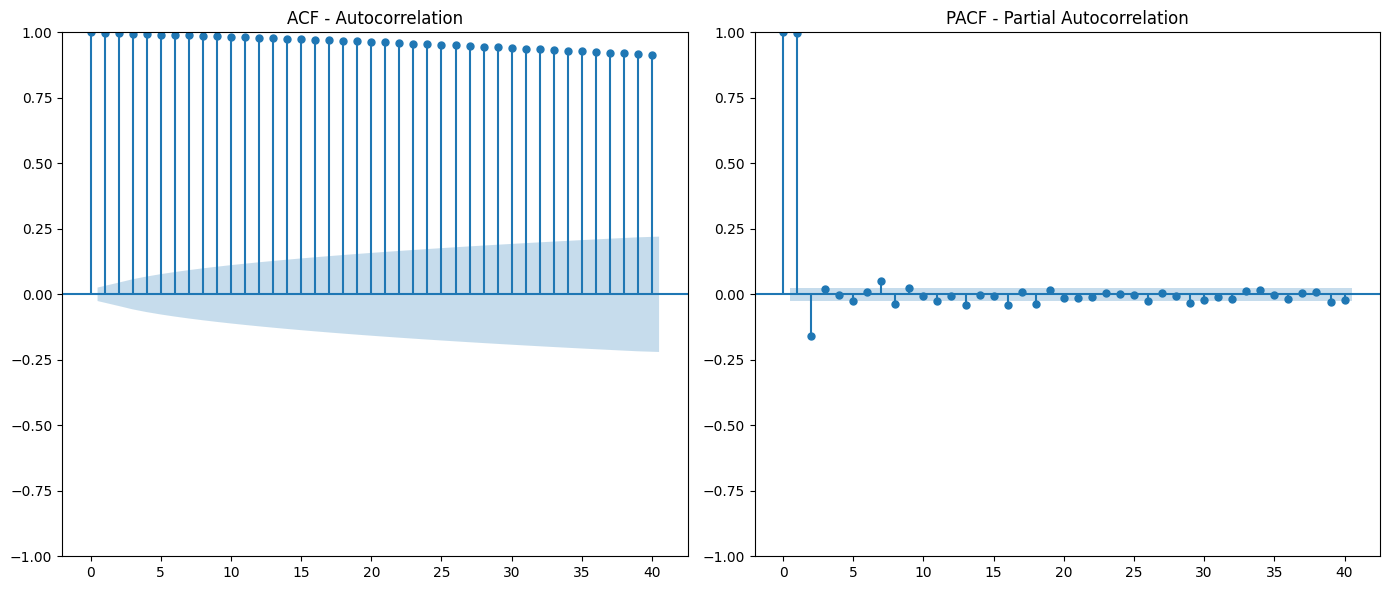

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# إذا كانت السلسلة الأصلية ثابتة كما أثبت اختبار ADF، نستخدمها كما هي
plt.figure(figsize=(14,6))

plt.subplot(1, 2, 1)
plot_acf(df['Price'], lags=40, ax=plt.gca())
plt.title('ACF - Autocorrelation')

plt.subplot(1, 2, 2)
plot_pacf(df['Price'], lags=40, ax=plt.gca(), method='ywm')
plt.title('PACF - Partial Autocorrelation')

plt.tight_layout()
plt.show()


In [ ]:
# حجم التدريب
train_size = int(len(df) * 0.8)

# تقسيم السلسلة الزمنية
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(f"Train size: {len(train)}, Test size: {len(test)}")


Train size: 4639, Test size: 1160


In [ ]:
!pip install statsmodels


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(1, 0, 1))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -6774.988
Date:                Wed, 30 Jul 2025   AIC                          13557.976
Time:                        10:33:12   BIC                          13583.745
Sample:                             0   HQIC                         13567.042
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.4878     11.329      5.957      0.000      45.283      89.692
ar.L1          0.9987      0.001   1674.067      0.000       0.998       1.000
ma.L1          0.2485      0.009     28.667      0.0

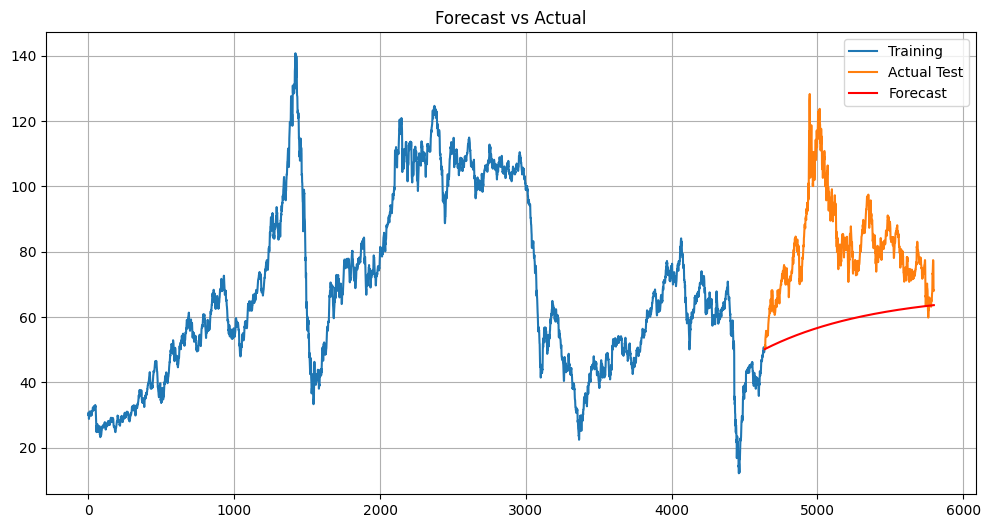

In [ ]:
# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')


MAE: 23.3816
RMSE: 27.1457


(1, 0, 0)

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -6913.487
Date:                Wed, 30 Jul 2025   AIC                          13832.975
Time:                        11:07:03   BIC                          13852.301
Sample:                             0   HQIC                         13839.774
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.4876     11.823      5.708      0.000      44.315      90.660
ar.L1          0.9991      0.000   2062.902      0.000       0.998       1.000
sigma2         1.1518      0.010    115.447      0.0

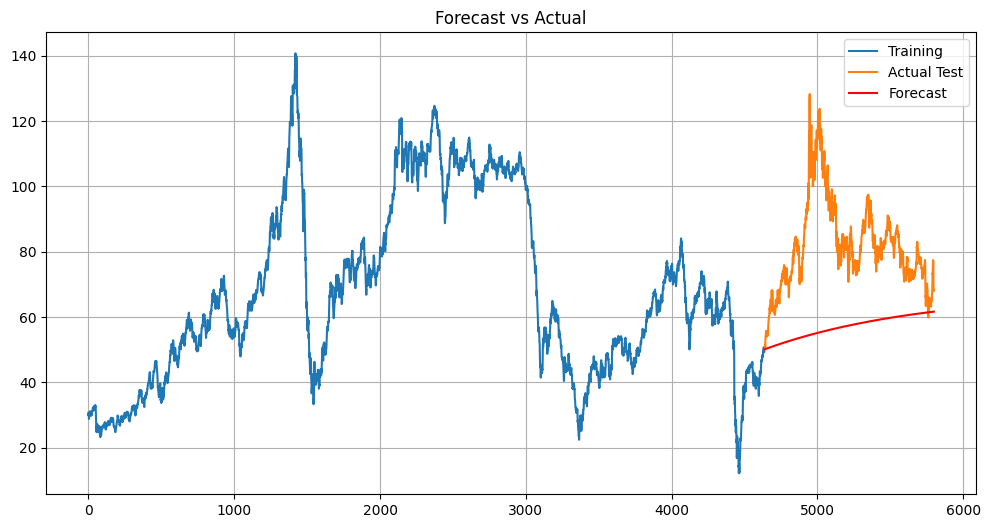

MAE: 24.9789
RMSE: 28.5601


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(1, 0, 0))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())

# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')




2,0,1

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(2, 0, 1)   Log Likelihood               -6774.967
Date:                Wed, 30 Jul 2025   AIC                          13559.933
Time:                        11:07:50   BIC                          13592.145
Sample:                             0   HQIC                         13571.266
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.4874     11.910      5.667      0.000      44.145      90.830
ar.L1          0.9944      0.042     23.789      0.000       0.912       1.076
ar.L2          0.0044      0.042      0.104      0.9

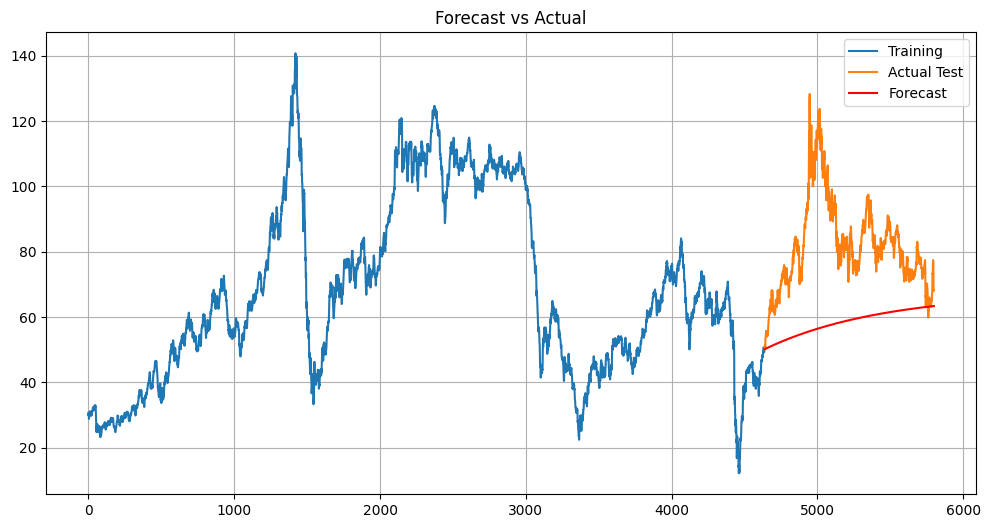

MAE: 23.6208
RMSE: 27.3593


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(2, 0, 1))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())

# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')




                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(1, 0, 2)   Log Likelihood               -6774.995
Date:                Wed, 30 Jul 2025   AIC                          13559.990
Time:                        12:44:13   BIC                          13592.202
Sample:                             0   HQIC                         13571.323
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.4878     11.230      6.010      0.000      45.478      89.498
ar.L1          0.9987      0.001   1675.639      0.000       0.998       1.000
ma.L1          0.2485      0.009     28.337      0.0

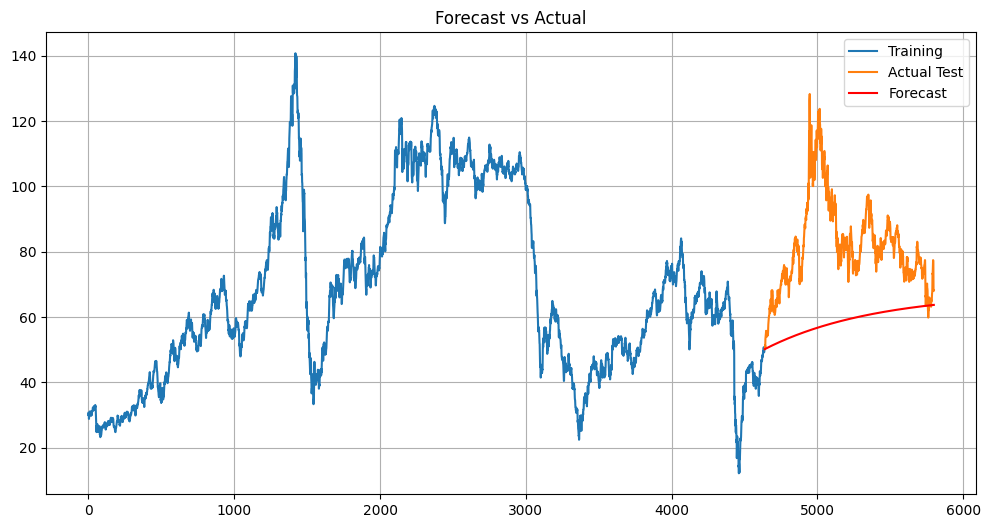

MAE: 23.3186
RMSE: 27.0892


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(1, 0, 2))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())

# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')




/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -6773.069
Date:                Wed, 30 Jul 2025   AIC                          13558.138
Time:                        11:19:16   BIC                          13596.791
Sample:                             0   HQIC                         13571.737
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.1446     13.446      4.919      0.000      39.792      92.497
ar.L1          0.2014      0.138      1.464      0.143      -0.068       0.471
ar.L2          0.7966      0.137      5.798      0.0

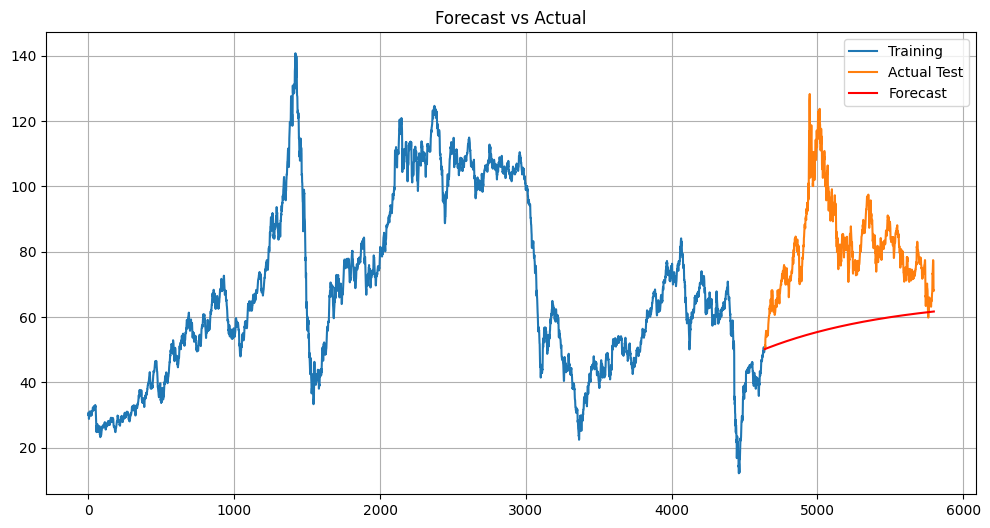

MAE: 24.7738
RMSE: 28.3534


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(2, 0, 2))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())

# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')




                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4639
Model:                 ARIMA(3, 0, 1)   Log Likelihood               -6773.075
Date:                Wed, 30 Jul 2025   AIC                          13558.150
Time:                        11:23:52   BIC                          13596.804
Sample:                             0   HQIC                         13571.749
                               - 4639                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.4768     21.754      3.102      0.002      24.840     110.114
ar.L1          0.5249      0.074      7.048      0.000       0.379       0.671
ar.L2          0.5977      0.097      6.175      0.0

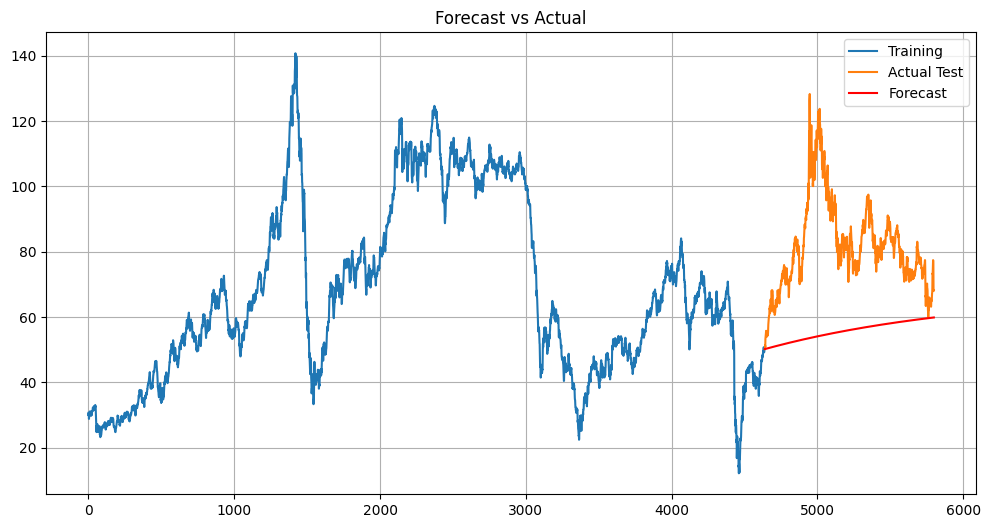

MAE: 26.2242
RMSE: 29.6474


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# بناء النموذج على بيانات التدريب
model = ARIMA(train['Price'], order=(3, 0, 1))
model_fit = model.fit()

# طباعة ملخص النموذج
print(model_fit.summary())

# التنبؤ بعدد خطوات = حجم test
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index  # لمطابقة الفهرسة الزمنية

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train['Price'], label='Training')
plt.plot(test['Price'], label='Actual Test')
plt.plot(forecast, label='Forecast', color='red')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test['Price'], forecast)
rmse = np.sqrt(mean_squared_error(test['Price'], forecast))

print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')




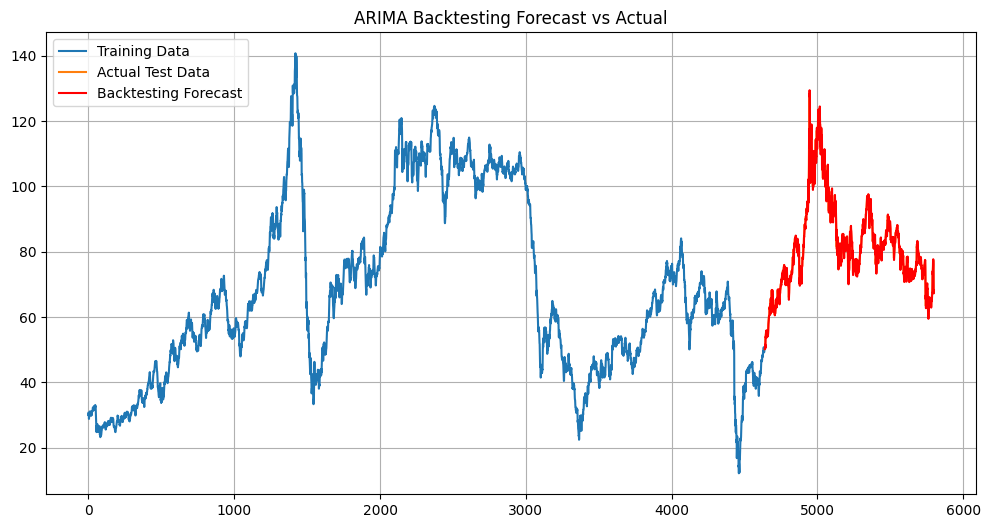

Backtesting MAE: 1.1273
Backtesting RMSE: 1.6299


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# بياناتك في df وعمود السعر 'Price'

# إعداد المتغيرات
data = df['Price']
train_size = int(len(data) * 0.8)  # 80% كحجم بداية نافذة التدريب
history = list(data[:train_size])  # نافذة التدريب الأولية
test = list(data[train_size:])     # بيانات الاختبار (20% المتبقية)

predictions = []

for t in range(len(test)):
    # بناء نموذج ARIMA على نافذة التدريب الحالية
    model = ARIMA(history, order=(1, 0, 1))
    model_fit = model.fit()

    # التنبؤ للنقطة التالية
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)

    # إضافة القيمة الحقيقية للنقطة لاستخدامها في تدريب المرة القادمة (توسيع النافذة)
    history.append(test[t])

# تحويل النتائج إلى pandas Series للفهرسة الزمنية وللرسم
pred_index = data.index[train_size:]
pred_series = pd.Series(predictions, index=pred_index)
test_series = pd.Series(test, index=pred_index)

# رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(data[:train_size], label='Training Data')
plt.plot(test_series, label='Actual Test Data')
plt.plot(pred_series, label='Backtesting Forecast', color='red')
plt.title('ARIMA Backtesting Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()

# حساب مقاييس الأداء
mae = mean_absolute_error(test_series, pred_series)
rmse = np.sqrt(mean_squared_error(test_series, pred_series))

print(f'Backtesting MAE: {mae:.4f}')
print(f'Backtesting RMSE: {rmse:.4f}')


In [ ]:
!pip install pytorch_lightning --quiet
!pip install u8darts --quiet


  0%|          | 0/1174 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
 23%|██▎       | 274/1174 [16:35<1:04:36,  4.31s/it]/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
 25%|██▍       | 292/1174 [17:44<1:04:55,  4.42s/it]/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_re

MAE: 8.9708
RMSE: 267.2971


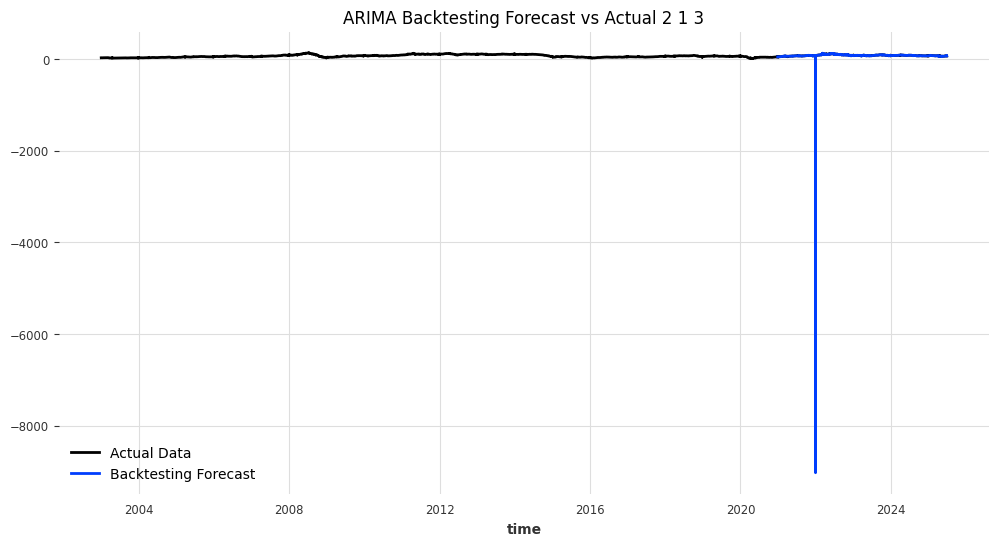

In [ ]:
from darts import TimeSeries
from darts.models import ARIMA
from darts.metrics import mae, rmse
import matplotlib.pyplot as plt

# تحويل بيانات السعر إلى TimeSeries مع ملء التواريخ المفقودة (تردد يوم عمل)
series = TimeSeries.from_series(df['Price'], fill_missing_dates=True, freq='B')

# إنشاء نموذج ARIMA مع معاملات (2,1,3)
model = ARIMA(p=2, d=1, q=3)

# تنفيذ backtesting
backtest_pred = model.historical_forecasts(
    series,
    start=0.8,            # بداية التوقع (80% من البيانات)
    forecast_horizon=1,   # توقع خطوة واحدة في كل مرة
    stride=1,             # تحريك النافذة خطوة بخطوة
    retrain=True,         # إعادة تدريب النموذج كل مرة
    verbose=True
)

# حساب مقاييس الخطأ على الفترة التي بدأ فيها التوقع
actual = series.drop_before(backtest_pred.start_time())
error_mae = mae(actual, backtest_pred)
error_rmse = rmse(actual, backtest_pred)

print(f'MAE: {error_mae:.4f}')
print(f'RMSE: {error_rmse:.4f}')

# رسم النتائج
plt.figure(figsize=(12,6))
series.plot(label='Actual Data')
backtest_pred.plot(label='Backtesting Forecast')
plt.title('ARIMA Backtesting Forecast vs Actual 2 1 3')
plt.legend()
plt.grid(True)
plt.show()


historical forecasts:   0%|          | 0/1174 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
historical forecasts:  12%|█▏        | 137/1174 [19:08<2:36:41,  9.07s/it]/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
historical forecasts:  13%|█▎        | 152/1174 [21:16<2:25:34,  8.55s/it]/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning

MAE: 1.1270
RMSE: 1.6308


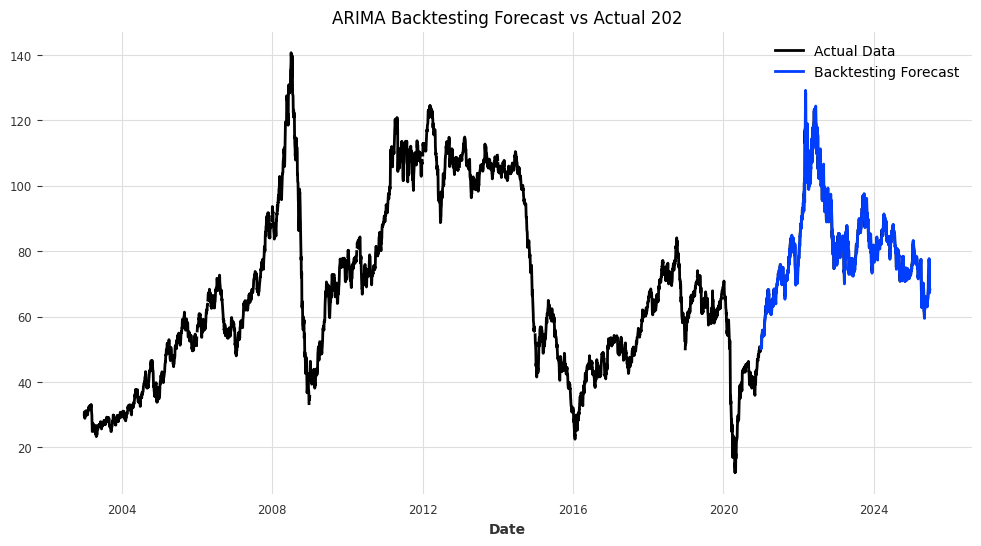

In [ ]:
from darts import TimeSeries
from darts.models import ARIMA
from darts.metrics import mae, rmse
import matplotlib.pyplot as plt

# تحويل بيانات السعر إلى TimeSeries مع ملء التواريخ المفقودة (تردد يوم عمل)
series = TimeSeries.from_series(df['Price'], fill_missing_dates=True, freq='B')

# إنشاء نموذج ARIMA مع معاملات (2,0,2)
model = ARIMA(p=2, d=0, q=2)

# تنفيذ backtesting
backtest_pred = model.historical_forecasts(
    series,
    start=0.8,            # بداية التوقع (80% من البيانات)
    forecast_horizon=1,   # توقع خطوة واحدة في كل مرة
    stride=1,             # تحريك النافذة خطوة بخطوة
    retrain=True,         # إعادة تدريب النموذج كل مرة
    verbose=True
)

# حساب مقاييس الخطأ على الفترة التي بدأ فيها التوقع
actual = series.drop_before(backtest_pred.start_time())
error_mae = mae(actual, backtest_pred)
error_rmse = rmse(actual, backtest_pred)

print(f'MAE: {error_mae:.4f}')
print(f'RMSE: {error_rmse:.4f}')


plt.figure(figsize=(12,6))
series.plot(label='Actual Data')
backtest_pred.plot(label='Backtesting Forecast')
plt.title('ARIMA Backtesting Forecast vs Actual 202')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
!pip uninstall -y u8darts statsforecast pmdarima
!pip install statsforecast>=1.4 pmdarima


Found existing installation: u8darts 0.36.0
Uninstalling u8darts-0.36.0:
  Successfully uninstalled u8darts-0.36.0
Found existing installation: statsforecast 2.0.2
Uninstalling statsforecast-2.0.2:
  Successfully uninstalled statsforecast-2.0.2


In [ ]:
!pip install statsforecast>=1.4 pmdarima

In [ ]:
!pip install sktime[all_extras]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.5/983.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.9/974.9 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 41.5 MB/s eta 0:0

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11


Best model:  ARIMA(2,1,3)(0,0,0)[0] intercept
Total fit time: 35.561 seconds

✅ المعاملات المختارة (p,d,q): (2, 1, 3)

📊 MAE: 27.2022
📊 RMSE: 30.4601


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


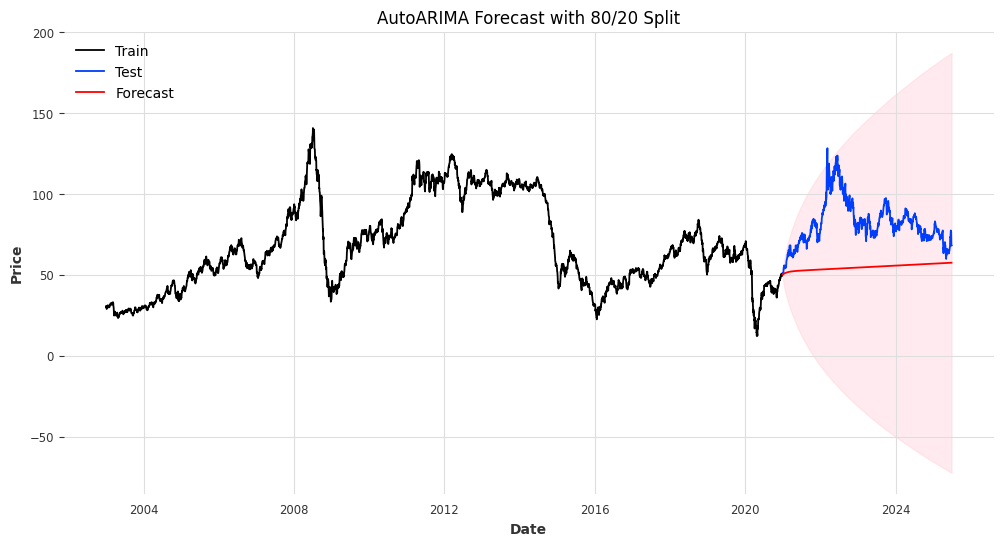

In [ ]:
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. تحميل وتنظيف البيانات
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/Dataset.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# 2. استخراج السلسلة الزمنية
series = df['Price']

# 3. تقسيم البيانات إلى 80% تدريب و20% اختبار
split_idx = int(len(series) * 0.8)
train, test = series[:split_idx], series[split_idx:]

# 4. تدريب نموذج AutoARIMA على بيانات التدريب فقط
model = pm.auto_arima(
    train,
    start_p=0, max_p=10,
    start_q=0, max_q=10,
    max_d=3,
    seasonal=False,
    stepwise=False,          # تعطيل البحث السريع لتجربة كل التركيبات
    n_jobs=-1,               # استخدام كل الأنوية المتوفرة لتسريع التدريب
    suppress_warnings=True,
    error_action='ignore',
    trace=True               # عرض تفاصيل البحث عن المعلمات
)

# 5. عرض المعلمات التي اختارها النموذج
print("\n✅ المعاملات المختارة (p,d,q):", model.order)

# 6. التنبؤ على مجموعة الاختبار
n_forecast = len(test)
forecast, conf_int = model.predict(n_periods=n_forecast, return_conf_int=True)

# 7. تقييم النموذج
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print(f"\n📊 MAE: {mae:.4f}")
print(f"📊 RMSE: {rmse:.4f}")

# 8. رسم النتائج
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.fill_between(test.index, conf_int[:, 0], conf_int[:, 1], color='pink', alpha=0.3)
plt.title('AutoARIMA Forecast with 80/20 Split')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


In [4]:
import pandas as pd

# load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/FirstPaperColabWork/Dataset.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# show us the first 10 rows
print(df.head(10))


print("\n--- date---")
print(df.index.to_series().diff().value_counts())


            Price
Date             
2003-01-02  30.05
2003-01-03  30.83
2003-01-06  30.71
2003-01-07  29.72
2003-01-08  28.86
2003-01-09  29.51
2003-01-10  29.82
2003-01-13  29.82
2003-01-14  30.21
2003-01-15  30.66

--- date---
Date
1 days    4612
3 days    1126
4 days      43
2 days      12
5 days       5
Name: count, dtype: int64
